In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
import sys
import os
from pathlib import Path

In [4]:
BASE_PATH = Path(os.path.abspath('')).parent.parent.parent
sys.path.append(str(BASE_PATH))

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import numpy as np

import matplotlib.pyplot as plt
import scienceplots

%matplotlib inline

# plt.style.use(['science','ieee'])
# plt.style.use(['science','nature'])

In [7]:
portfolio = pd.read_csv('sp_portfolio_2025_07_09.csv')
portfolio = portfolio.fillna(0.)
portfolio["Date"] = pd.to_datetime(portfolio["Date"], utc=True)#.dt.date
# portfolio = portfolio[portfolio.Date <= datetime.date(2024, 8, 2)]
portfolio = portfolio.set_index("Date")
portfolio = portfolio.astype(float)
# portfolio = portfolio.drop(columns=['TIA-USD', 'OP-USD', 'UNI-USD', 'ARB-USD', 'SHIB-USD'], axis=1)
# portfolio = portfolio[old_portfolio.columns]
portfolio = portfolio[portfolio.mean().sort_values(ascending=False).index]

In [8]:
monthly_portfolio = portfolio.resample("M").sum()
monthly_portfolio_std = portfolio.resample("M").std()

returns = pd.DataFrame(monthly_portfolio.mean(), columns=["Return"])
risk = pd.DataFrame(monthly_portfolio_std.std(), columns=["Risk"])

df_risk_return = returns.merge(risk, left_index=True, right_index=True)

/var/folders/pr/c2dbtqtn2td9ylt9lvrqnrxc0000gn/T/ipykernel_12878/957110852.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_portfolio = portfolio.resample("M").sum()
/var/folders/pr/c2dbtqtn2td9ylt9lvrqnrxc0000gn/T/ipykernel_12878/957110852.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_portfolio_std = portfolio.resample("M").std()


In [9]:
import numpy as np

# Generate LaTeX table
table = "\\begin{table}[h]\n"
table += "\\centering\n"
table += "\\begin{tabular}{lcc}\n"
table += "\\hline\n"
table += "Stock Symbol & Mean Daily Returns $\\pm$ Daily Risk \\\\\n"
table += "\\hline\n"
for i in range (len(df_risk_return.index)):
    ticker=df_risk_return.index[i]
    x=df_risk_return.loc[ticker, "Risk"]
    y=df_risk_return.loc[ticker, "Return"]
    table += f"{ticker} & ${y:.3f} \\pm {x:.3f}$ \\\\\n"
table += "\\hline\n"
table += "\\end{tabular}\n"
table += "\\caption{Stocks Daily Risks and Returns}\n"
table += "\\end{table}\n"

print(table)


\begin{table}[h]
\centering
\begin{tabular}{lcc}
\hline
Stock Symbol & Mean Daily Returns $\pm$ Daily Risk \\
\hline
NVDA & $0.038 \pm 0.012$ \\
AXON & $0.037 \pm 0.013$ \\
SMCI & $0.034 \pm 0.024$ \\
ENPH & $0.030 \pm 0.017$ \\
PLTR & $0.030 \pm 0.024$ \\
TSLA & $0.029 \pm 0.014$ \\
AVGO & $0.028 \pm 0.012$ \\
AMD & $0.028 \pm 0.011$ \\
FTNT & $0.027 \pm 0.011$ \\
VST & $0.027 \pm 0.015$ \\
FICO & $0.026 \pm 0.013$ \\
LLY & $0.026 \pm 0.008$ \\
PWR & $0.025 \pm 0.009$ \\
KLAC & $0.025 \pm 0.011$ \\
CMG & $0.025 \pm 0.010$ \\
CRWD & $0.024 \pm 0.017$ \\
JBL & $0.024 \pm 0.011$ \\
PANW & $0.023 \pm 0.011$ \\
DECK & $0.023 \pm 0.012$ \\
NOW & $0.023 \pm 0.010$ \\
CDNS & $0.022 \pm 0.009$ \\
CEG & $0.022 \pm 0.017$ \\
WSM & $0.022 \pm 0.013$ \\
TPL & $0.022 \pm 0.013$ \\
ANET & $0.022 \pm 0.012$ \\
KKR & $0.022 \pm 0.011$ \\
TDG & $0.021 \pm 0.013$ \\
MPWR & $0.021 \pm 0.013$ \\
TT & $0.021 \pm 0.008$ \\
CARR & $0.021 \pm 0.013$ \\
HWM & $0.021 \pm 0.014$ \\
BX & $0.021 \pm 0.011$ \\
SNPS

Text(0, 0.5, 'Cumulative Log Returns')

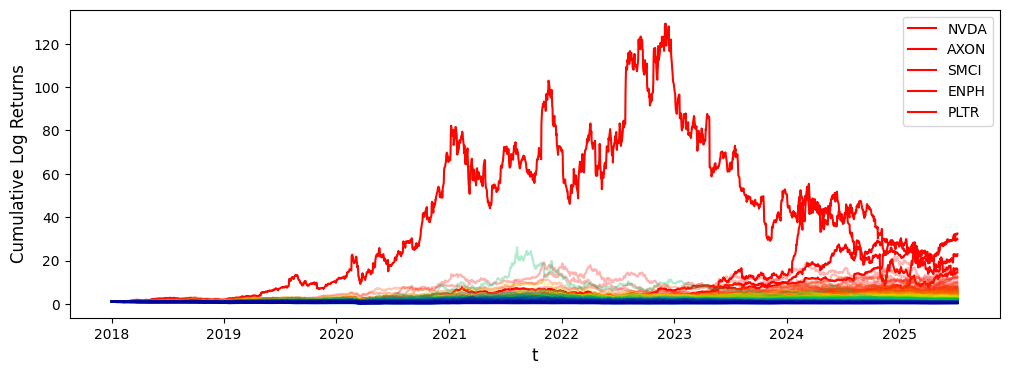

In [10]:
from colour import Color

blue = Color("red", luminance=0.5)
colors = list(blue.range_to(Color("blue", luminance=0.3), len(portfolio.columns)))

# with plt.style.context(['science', 'ieee', 'no-latex']):
fig, ax = plt.subplots(figsize=(12, 4))
i = 0
for col in portfolio.columns:
    if i <=4 :
        plt.plot(np.exp(portfolio[col].cumsum()), color=colors[i].rgb, linestyle="-", label=col)
    else:
        plt.plot(np.exp(portfolio[col].cumsum()), color=colors[i].rgb, alpha=0.3, linestyle="-", label=None)
    i += 1
plt.legend()
plt.xlabel('t', fontsize=12)
plt.ylabel('Cumulative Log Returns', fontsize=12)
    # plt.savefig('01_classes_highlighting_stocks.jpg', dpi=600)

In [ ]:
gamma_vec = np.linspace(0., 1.0, 11)

In [ ]:
gamma_vec

In [ ]:
gamma_hyper_policies = {
    f"D TS {i}": {
        "policy_name": "BetaDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i]},
        "agents": [],
    }
    for i in range(len(gamma_vec))
}
gamma_hyper_policies.update(
    {   
        f"ADTS (min) {i}": {
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "min", "w": 50},
            "agents": [],
        }
        for i in range(len(gamma_vec))
    }
)
gamma_hyper_policies.update(
    {   
        f"ADTS (mean) {i}": {
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "mean", "w": 50},
            "agents": [],
        }
        for i in range(len(gamma_vec))
    }
)
gamma_hyper_policies.update(
    {   
        f"ADTS (max) {i}": {
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "max", "w": 50},
            "agents": [],
        }
        for i in range(len(gamma_vec))
    }
)
gamma_hyper_policies.update(
    {   
        f"FDSWTS (min) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "min", "n": 50},
            "agents": [],
        }
        for i in range(len(gamma_vec))
    }
)
gamma_hyper_policies.update(
    {   
        f"FDSWTS (mean) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "mean", "n": 50},
            "agents": [],
        }
        for i in range(len(gamma_vec))
    }
)
gamma_hyper_policies.update(
    {   
        f"FDSWTS (max) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "max", "n": 50},
            "agents": [],
        }
        for i in range(len(gamma_vec))
    }
)
# gamma_hyper_policies.update(
#     {   
#         f"Classical TS {i}": {
#             "policy_name": "ThompsonSampling",
#             "args": {"n_arms": portfolio.shape[1]},
#             "agents": [],
#         }
#         for i in range(len(gamma_vec))
#     }
# )

In [ ]:
from bandits_lib.replay_engines.interface import BacktestInterface, interpolate_colors

gamma_bandit_backtester = BacktestInterface(
    bandit_policies=gamma_hyper_policies,
    n_simulations=5,
    reward_function="WindowedReturnArm",
    reward_function_args=dict(window=60),
    portfolio=portfolio,
)
gamma_bandit_backtester.run(n_threads=3)

In [ ]:
groups = ["ADTS (min)", "ADTS (mean)", "ADTS (max)", "FDSWTS (min)", "FDSWTS (mean)", "FDSWTS (max)"]
markers = ["s", "s", "s", "^", "^", "^"]
results_dict = {}
for g in groups:
    results_dict[g] = {
        "gamma_vec": gamma_vec,
        "regret": [],
        "reward": [],
    }
    for k, v in gamma_bandit_backtester.bandit_policies.items():
        if g in k:
            results_dict[g]["regret"].append(v["mean_regret"].sum())
            results_dict[g]["reward"].append(v["mean_reward"].sum())

In [ ]:
from bandits_lib.replay_engines.interface import interpolate_colors

In [ ]:
color_start: str = "#1f77b4"
color_end: str = "#ff7f0e"
colors = interpolate_colors(color_start, color_end, len(results_dict))

In [ ]:
from colour import Color

blue = Color("orange")
colors = list(blue.range_to(Color("blue", luminance=0.3), len(results_dict)))

x_min = 0.79
x_max = 1.01
y_min = 0.
y_max = 1.5

with plt.style.context(['science', 'ieee', 'no-latex']):
    fig, ax = plt.subplots(figsize=(8, 4))
    legend = []
    i = 0
    for policy in results_dict.keys():
        if len(results_dict[policy]['reward']) > 0:
            plt.plot(results_dict[policy]["gamma_vec"], results_dict[policy]["reward"], markers[i], markersize=3, label=policy, color=colors[i].rgb, linestyle="-")
            i+=1    
    plt.xlabel(r'$\gamma$')
    plt.ylabel('Cumulative Log-Returns')
    plt.legend(loc='upper right')
    plt.ylim([0, 5.0])
    plt.savefig('04_effect_of_gamma_3.jpg', dpi=600)

In [ ]:
w_vec = np.linspace(0, 300, 13)
w_vec[0]= 1

In [ ]:
w_vec

In [ ]:
gamma = 0.6

w_polices = {   
    f"ADTS (min) {i}": {
        "policy_name": "AdaptiveDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "min", "w": int(w_vec[i])},
        "agents": [],
    }
    for i in range(len(w_vec))
}
w_polices.update(
    {   
        f"ADTS (mean) {i}": {
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "mean", "w": int(w_vec[i])},
            "agents": [],
        }
        for i in range(len(w_vec))
    }
)
w_polices.update(
    {   
        f"ADTS (max) {i}": {
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "max", "w": int(w_vec[i])},
            "agents": [],
        }
        for i in range(len(w_vec))
    }
)
w_polices.update(
    {   
        f"FDSWTS (min) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "min", "n": int(w_vec[i])},
            "agents": [],
        }
        for i in range(len(w_vec))
    }
)
w_polices.update(
    {   
        f"FDSWTS (mean) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "mean", "n": int(w_vec[i])},
            "agents": [],
        }
        for i in range(len(w_vec))
    }
)
w_polices.update(
    {   
        f"FDSWTS (max) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "max", "n": int(w_vec[i])},
            "agents": [],
        }
        for i in range(len(w_vec))
    }
)

In [ ]:
from replay_engines.interface import BacktestInterface

w_bandit_backtester = BacktestInterface(
    bandit_policies=w_polices,
    n_simulations=10,
    reward_function="WindowedReturnArm",
    reward_function_args=dict(window=60),
    portfolio=portfolio,
)
w_bandit_backtester.run(n_threads=3)

In [ ]:
groups = ["ADTS (min)", "ADTS (mean)", "ADTS (max)", "FDSWTS (min)", "FDSWTS (mean)", "FDSWTS (max)"]
markers = ["s", "s", "s", "^", "^", "^"]
line_styles = ["-", "-", "-", "--", "--", "--"]
results_dict = {}
for g in groups:
    results_dict[g] = {
        "w_vec": w_vec,
        "regret": [],
        "reward": [],
    }
    for k, v in w_bandit_backtester.bandit_policies.items():
        if g in k:
            results_dict[g]["regret"].append(v["mean_regret"].sum())
            results_dict[g]["reward"].append(v["mean_reward"].sum())

In [ ]:
from colour import Color

blue = Color("orange")
colors = list(blue.range_to(Color("blue", luminance=0.3), len(results_dict)))

with plt.style.context(['science', 'ieee', 'no-latex']):
    fig, ax = plt.subplots(figsize=(6, 3))
    legend = []
    i = 0
    for policy in results_dict.keys():
        if len(results_dict[policy]['reward']) > 0:
            plt.plot(results_dict[policy]["w_vec"], results_dict[policy]["reward"], markers[i], markersize=2, label=policy, color=colors[i].rgb, linestyle="-")
            i+=1    
    plt.xlabel('w')
    plt.ylabel('Total Return')
    plt.legend()
    plt.savefig('04_effect_of_w_2.jpg', dpi=600)

## 3- Investigating the Rewards and Regrets

In [11]:
bandit_policies = {
    "ADTS (min)": {
        "policy_name": "AdaptiveDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "min", "w": 100},
    },
    # "ADTS (max)": {
    #     "policy_name": "AdaptiveDiscountedThompsonSampling",
    #     "args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "max", "w": 100},
    # },
    "ADTS (mean)": {
        "policy_name": "AdaptiveDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
    },
    "F-DSW TS (min)": {
        "policy_name": "CavenaghiFDSWTS",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "min", "n": 100},
    },
    # "F-DSW TS (max)": {
    #     "policy_name": "CavenaghiFDSWTS",
    #     "args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "max", "n": 100},
    # },
    "F-DSW TS (mean)": {
        "policy_name": "CavenaghiFDSWTS",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "mean", "n": 100},
    },
    "D TS": {
        "policy_name": "BetaDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.99},
    },
    "Classical TS": {
        "policy_name": "ThompsonSampling",
        "args": {"n_arms": portfolio.shape[1]},
    },
    "D UCB": {
        "policy_name": "DiscountedUCB1",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.1},
    },
    "SW UCB": {
        "policy_name": "SlidingWindowUCB1",
        "args": {"n_arms": portfolio.shape[1], "w": 100},
    },
    "UCB1": {
        "policy_name": "UCB1",
        "args": {"n_arms": portfolio.shape[1]},
    },
    # "$\epsilon$-Greedy": {
    #     "policy_name": "EpsilonGreedy",
    #     "args": {"n_arms": portfolio.shape[1], "epsilon": 0.02},
    # },
}

In [12]:
from bandits_lib.replay_engines.interface import BacktestInterface

crypto_bandit_backtester = BacktestInterface(
    bandit_policies=bandit_policies,
    n_simulations=50,
    reward_function="WindowedReturnArm",
    reward_function_args=dict(window=60),
    portfolio=portfolio,
)
crypto_bandit_backtester.run(n_threads=3)


  0%|                                                                                                                                           | 0/50 [00:00<?, ?it/s]

  4%|█████▏                                                                                                                             | 2/50 [00:21<08:40, 10.84s/it]

  4%|█████▏                                                                                                                             | 2/50 [00:40<13:44, 17.18s/it]

  8%|██████████▍                                                                                                                        | 4/50 [00:51<11:11, 14.60s/it]

 14%|██████████████████▎                                                                                                                | 7/50 [01:21<08:07, 11.33s/it]

 18%|███████████████████████▌                                                                                                           | 9/50 [01:44<07:4

In [13]:
from colour import Color
import numpy as np

blue = Color("orange", luminance=0.5)
colors = list(blue.range_to(Color("blue", luminance=0.3), len(crypto_bandit_backtester.bandit_policies)))

In [ ]:
# crypto_bandit_backtester.plot_regrets(
#     save_fig=True,
#     figure_name="02_cumulative_regrets.jpg",
#     # plot_log=True,
#     personalized_colors=[c.rgb for c in colors]
# )

In [15]:
from bandits_lib.replay_engines.interface import interpolate_colors

def plot_rewards(obj,                 
                 save_fig: bool = False,
                 figure_name: str = None,
                 oracle: np.ndarray = None,
                 oracle_name: str = "Oracle",
                 personalized_colors: list = None,
                 color_start: str = "#1f77b4",
                 color_end: str = "#ff7f0e"):

    if save_fig and figure_name is None:
        raise ValueError("Please provide a figure name to save the plot.")
    
    # Default Matplotlib blue and orange
    color_vector_size = len(obj.bandit_policies)
    colors = interpolate_colors(color_start, color_end, color_vector_size)
    if personalized_colors is not None:
        colors = personalized_colors
    
    with plt.style.context(['science', 'ieee', 'no-latex']):
        plt.subplots(figsize=(6, 3))
    
        if oracle is not None:
            plt.plot(obj.portfolio.index, np.exp(np.cumsum(oracle)), color='black', linestyle='-', label=oracle_name)
    
        i = 0
        for policy, output in obj.bandit_policies.items():
            plt.plot(obj.portfolio.index, np.exp(np.cumsum(output['mean_reward'])), color=colors[i], linestyle='-', label=policy)
            i += 1
        plt.legend(loc='upper left', fontsize=7)
        plt.xlabel('t', fontsize=10)
        plt.ylabel('Cumulative Returns', fontsize=10)
        if save_fig:
            plt.savefig(figure_name, dpi=600)

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Define the number of colors N
N = 2

# Default Matplotlib colors
matplotlib_orange = np.array(plt.cm.tab10.colors[1])  # index 1 corresponds to default orange
matplotlib_blue = np.array(plt.cm.tab10.colors[0])    # index 0 corresponds to default blue
matplotlib_green = np.array(plt.cm.tab10.colors[2])    # index 0 corresponds to default green
matplotlib_grey = np.array([0.5, 0.5, 0.5])    # index 0 corresponds to default green

# Define light versions by increasing the brightness (closer to white)
light_orange = matplotlib_orange + (1 - matplotlib_orange) * 0.4
light_blue = matplotlib_blue + (1 - matplotlib_blue) * 0.3
light_green = matplotlib_green + (1 - matplotlib_green) * 0.4
light_grey = matplotlib_grey + (1 - matplotlib_grey) * 0.4

# Interpolate between the colors
interpolated_orange_colors = [matplotlib_orange + (light_orange - matplotlib_orange) * i / (N - 1) for i in range(N)]
interpolated_blue_colors = [matplotlib_blue + (light_blue - matplotlib_blue) * i / (N - 1) for i in range(N)]
interpolated_green_colors = [matplotlib_green + (light_green - matplotlib_green) * i / (N - 1) for i in range(N)]

N=3
interpolated_grey_colors = [matplotlib_grey + (light_grey - matplotlib_grey) * i / (N - 1) for i in range(N)]


# interpolated_blue_colors.reverse()
interpolated_green_colors.reverse()

In [17]:
colors = interpolated_blue_colors + interpolated_orange_colors + interpolated_green_colors + interpolated_grey_colors

In [18]:
import yfinance as yf
import re


def retrieve_sp_returns():
    sp = ["^GSPC"]
    yf_obj = yf.Tickers(re.sub(r"'|,|\[|\]", "", str(sp)))
    today = datetime.date.today()

    df_sp = pd.DataFrame()
    for ticker in yf_obj.tickers.keys():
        df_ticker = yf_obj.tickers[ticker].history(start="2018-01-01", end="2025-01-11")
        df_ticker["ticker"] = ticker
        df_ticker["return"] = np.log(df_ticker["Close"] / df_ticker["Close"].shift(1))
        df_ticker["return"] = df_ticker["return"].fillna(0)
        df_ticker = df_ticker.reset_index()
        df_ticker = df_ticker[["Date", "ticker", "return"]]
        df_sp = pd.concat([df_sp, df_ticker])
    df_sp = df_sp.pivot_table(values="return", index="Date", columns="ticker")
    return df_sp

In [19]:
sp = retrieve_sp_returns()

In [20]:
for bandit_policy, output in crypto_bandit_backtester.bandit_policies.items():
    print(bandit_policy, output['mean_regret'].sum())

ADTS (min) 1075.9443191527093
ADTS (mean) 1077.0653835205158
F-DSW TS (min) 1077.7167496093227
F-DSW TS (mean) 1077.4606357116263
D TS 1078.657161068589
Classical TS 1079.1474537476142
D UCB 1065.956680316405
SW UCB 1084.6199583125076
UCB1 1084.7733764486097


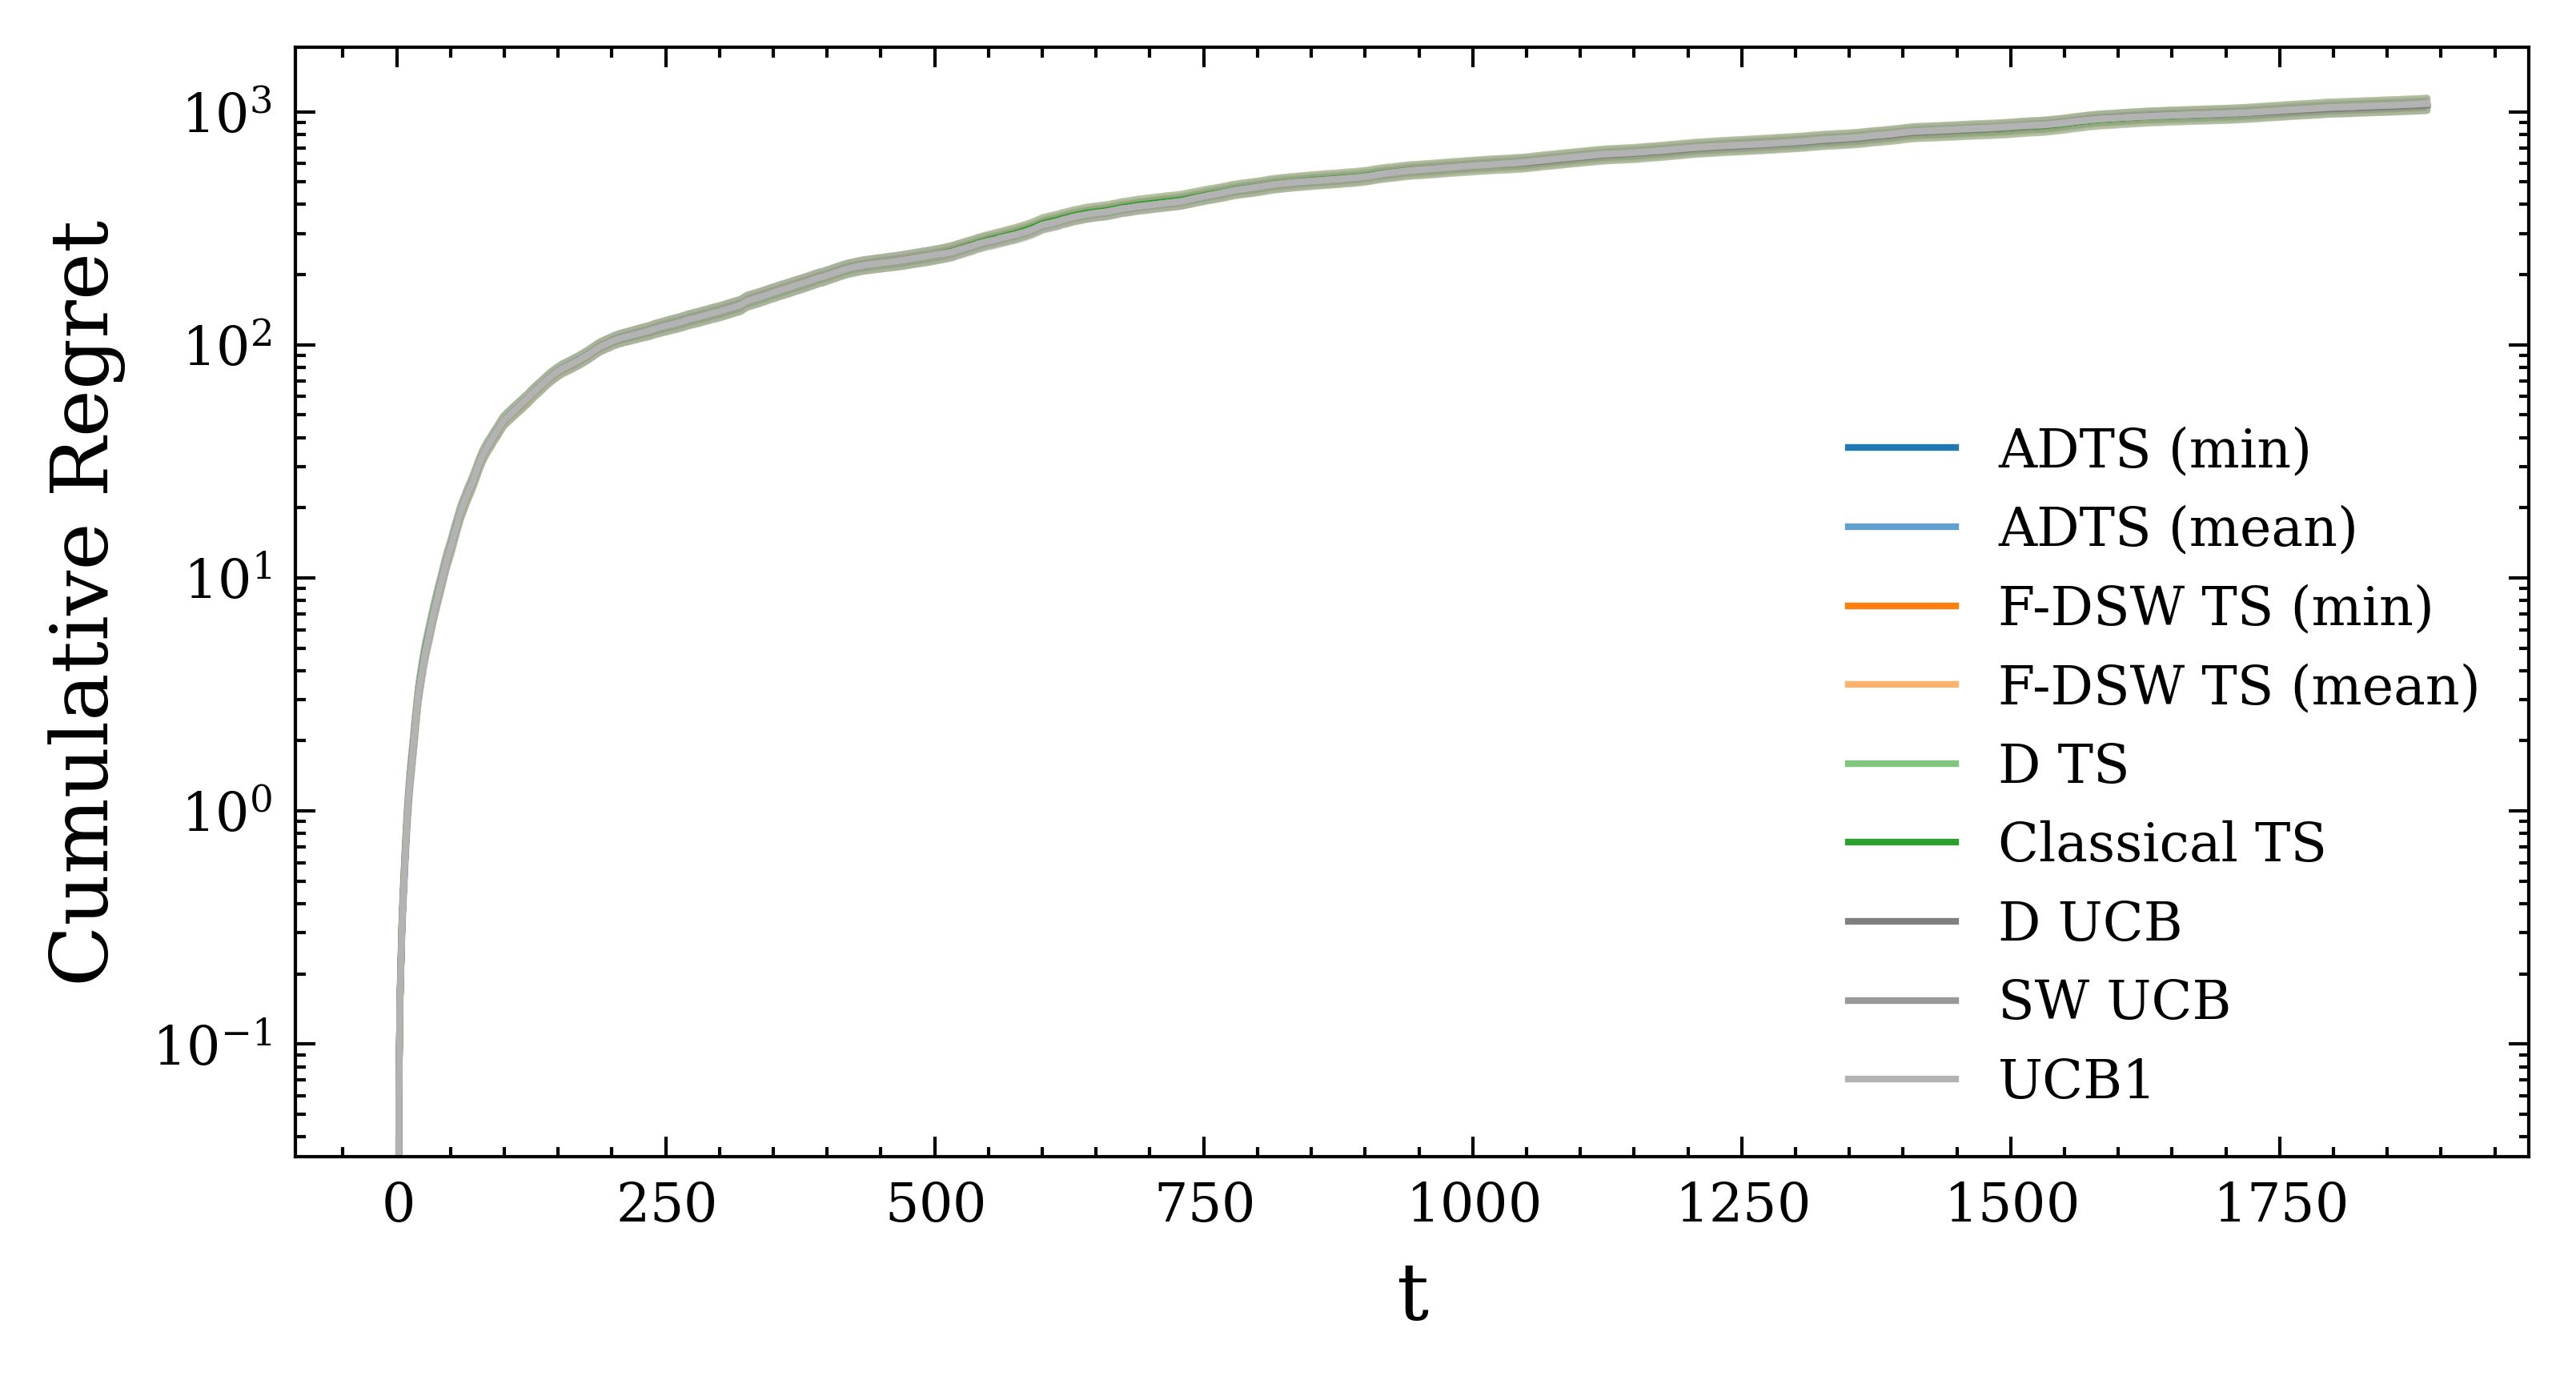

In [21]:
crypto_bandit_backtester.plot_regrets(
    personalized_colors=colors,
    plot_log=True,
)

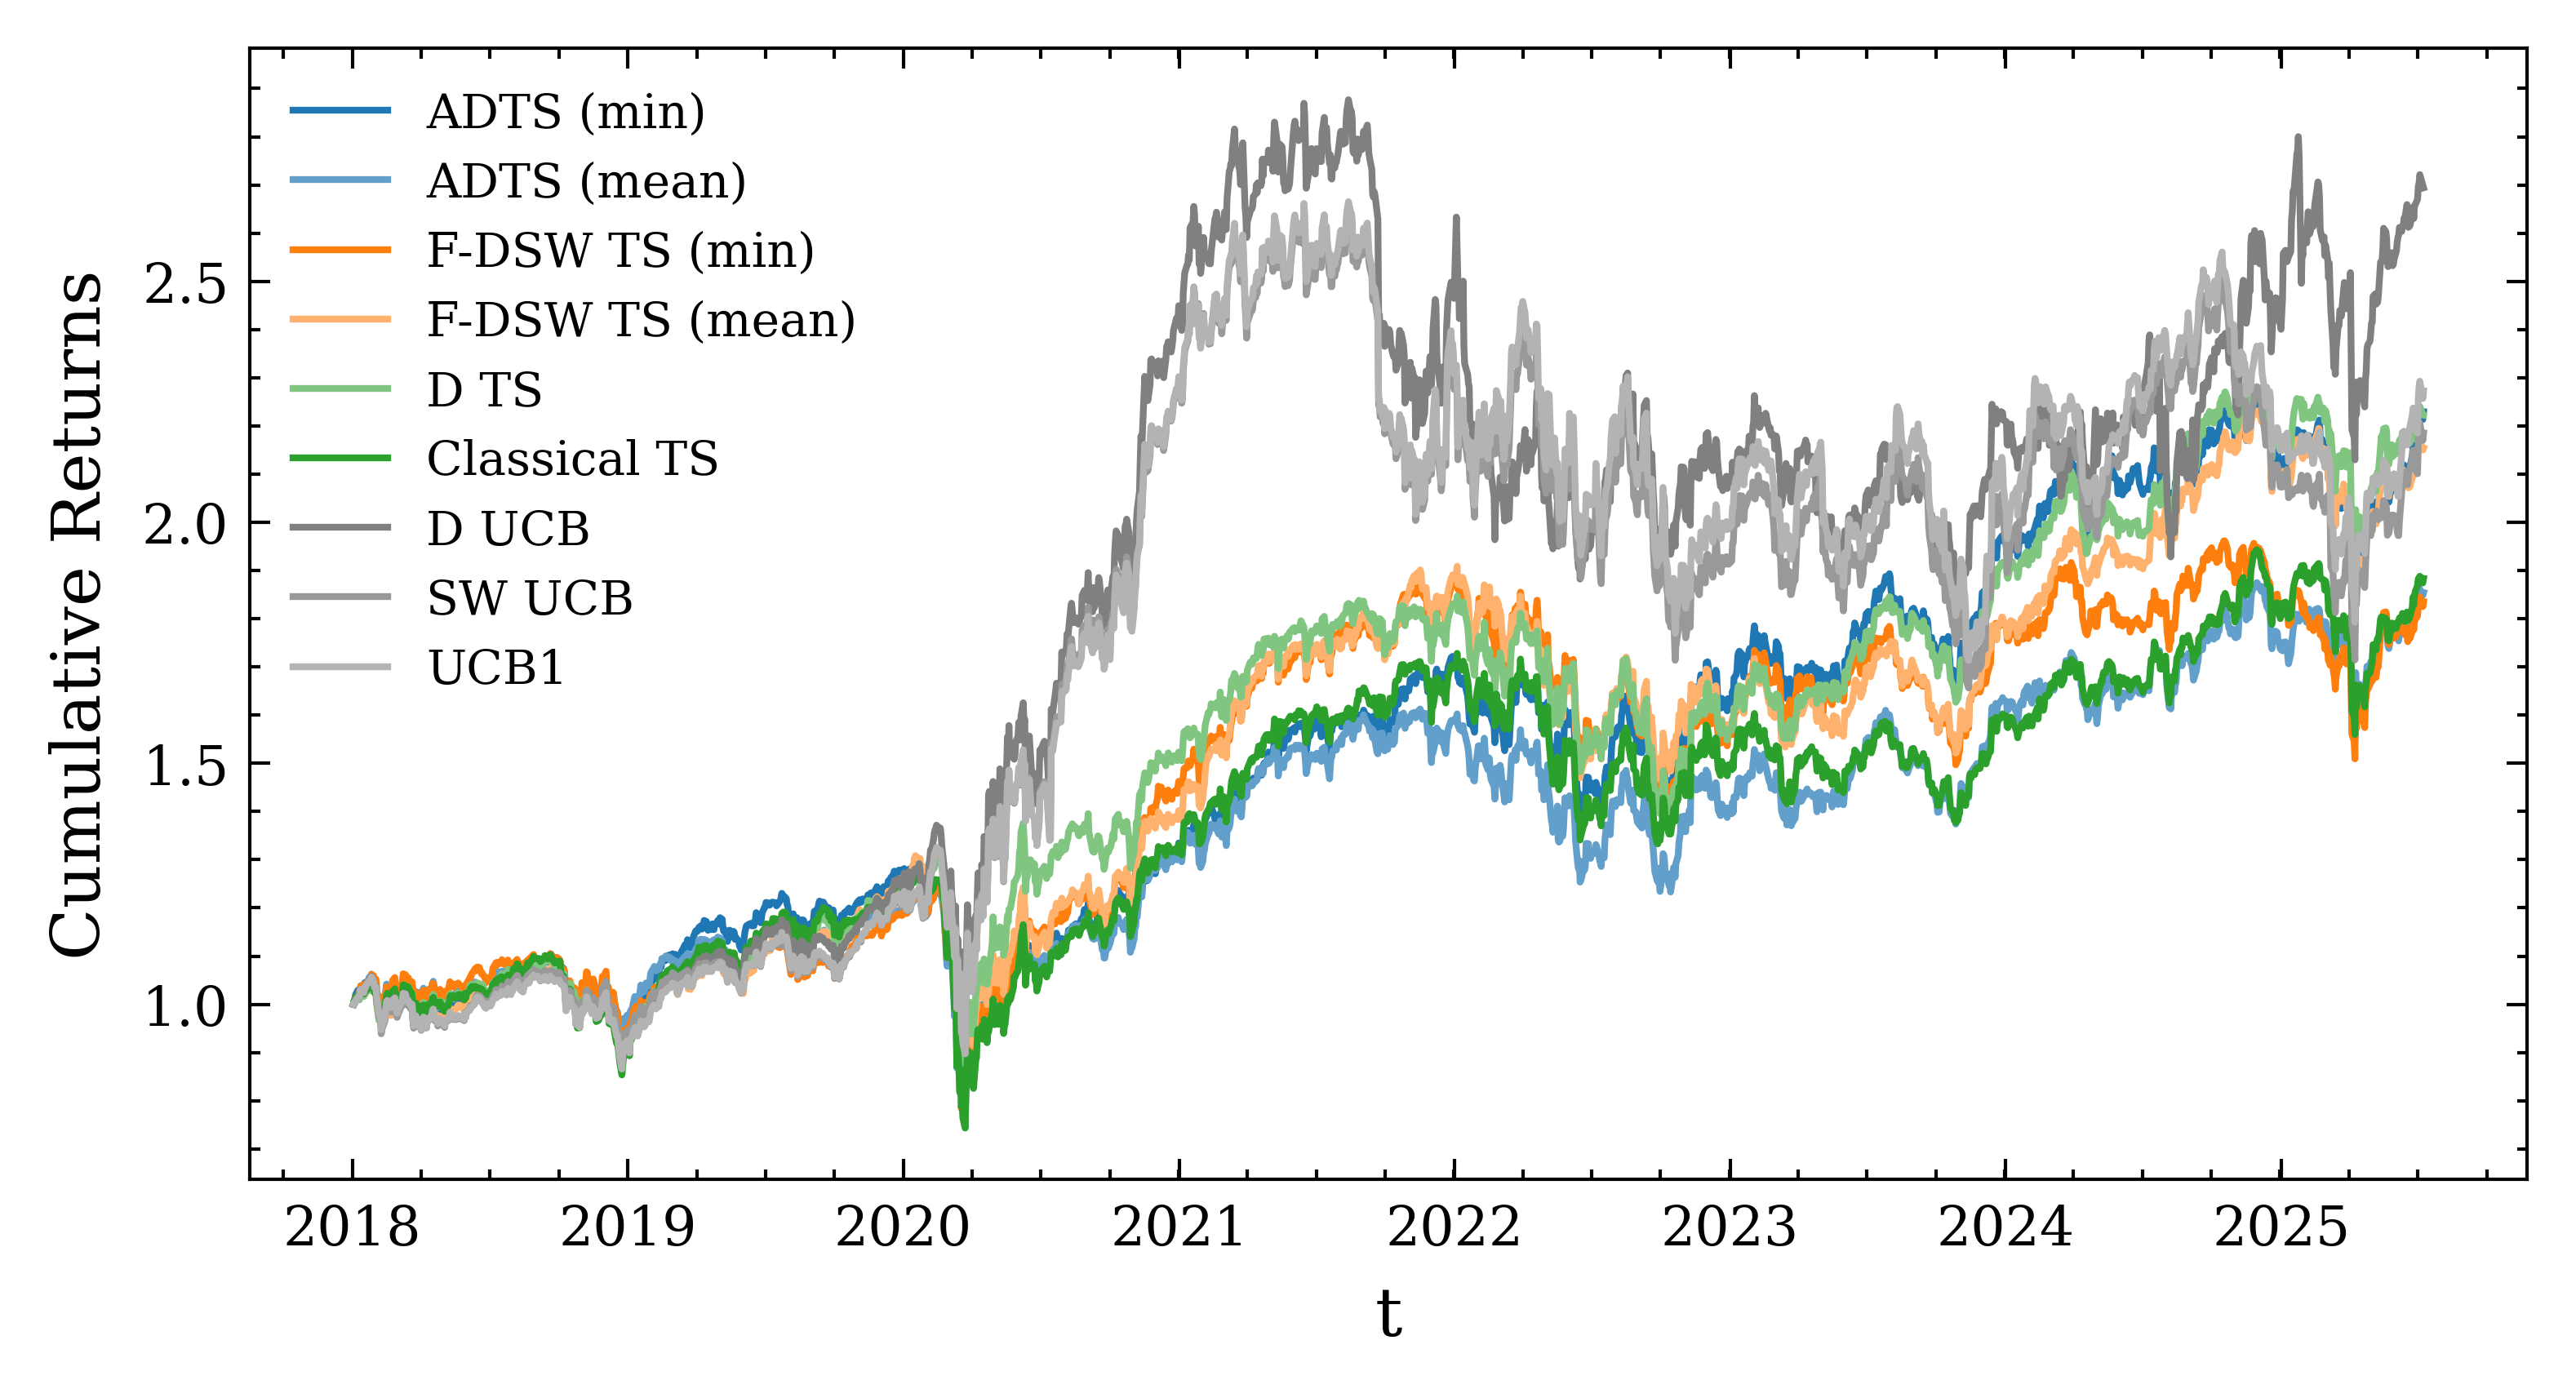

In [24]:
plot_rewards(
    crypto_bandit_backtester,
    # save_fig=True,
    # figure_name="03_rewards_versus_oracle.jpg",
    # oracle_name="S&P 500",
    # oracle=sp['^GSPC'].values,
    personalized_colors=colors
)
# plt.yscale('log')

In [ ]:
def calculate_metrics(log_returns):
    returns = np.exp(log_returns) - 1
    cumulative_returns = np.cumprod(1 + returns) - 1
    daily_returns = np.mean(returns)
    volatility = np.std(returns)
    drawdown = np.min(cumulative_returns - np.maximum.accumulate(cumulative_returns))
    win_rate = np.sum(returns > 0) / len(returns)
    
    # Risk-adjusted ratios
    risk_free_rate = 0.0  # Assuming risk-free rate is zero
    excess_returns = returns - risk_free_rate
    sharpe_ratio = np.mean(excess_returns) / np.std(excess_returns) * np.sqrt(252)
    downside_deviation = np.std(excess_returns[excess_returns < 0])
    sortino_ratio = np.mean(excess_returns) / downside_deviation
    calmar_ratio = np.mean(excess_returns) / drawdown
    
    return {
        "Cumulative Returns": cumulative_returns[-1],
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": drawdown,
#         "Average Daily Returns": daily_returns,
        "Std. Deviation": volatility,
        # "Win Rate": win_rate,
        # "Sortino Ratio": sortino_ratio,
#         "Calmar Ratio": calmar_ratio
    }

In [ ]:
def aggregate_metrics(policies: dict):
    portfolio_history = {}
    index = []
    for policy, output in policies.items():
        metrics_dict = calculate_metrics(output["mean_reward"])
        for k, v in metrics_dict.items():
            if k not in portfolio_history.keys():
                portfolio_history[k] = [v]
            else:
                portfolio_history[k].append(v)
        index.append(policy)
    df = pd.DataFrame(portfolio_history, index=index)
    df = df.sort_values("Cumulative Returns", ascending=False)
    return df

In [ ]:
policies = crypto_bandit_backtester.bandit_policies.copy()
policies['S\&P'] = {
    "mean_reward": sp['^GSPC'].values
}

df_metrics = aggregate_metrics(policies)
df_metrics.to_csv('backtest_linear_bandits_crypto.csv')
df_metrics

In [ ]:
df_metrics = pd.read_csv("backtest_linear_bandits_crypto.csv")

In [ ]:
df_metrics

In [ ]:
df_metrics = df_metrics.set_index("Unnamed: 0")

In [ ]:
import numpy as np

# Generate LaTeX table
table = "\\begin{table}[h]\n"
table += "\\centering\n"
table += "\\begin{tabular}{lcccccc}\n"
table += "\\hline\n"
table += "Policy & Cumulative Returns & SR & MDD & $\sigma$ \\\n"
table += "\\hline\n"
for i in range(len(df_metrics.index)):
    ticker=df_metrics.index[i]
    results_list = list(df_metrics.loc[ticker, :])
    results_list = [f"${abs(float(r)):.2f}$" if r > 1.0 else f"${abs(float(r)):.3f}$" for r in results_list]
    start_line = f"{ticker} & "
    end_line = "\\\\\n"
    table +=  start_line + " & ".join(results_list) + end_line
table += "\\hline\n"
table += "\\end{tabular}\n"
table += "\\caption{Stocks Daily Risks and Returns}\n"
table += "\\end{table}\n"

print(table)

## 4- Drift Analysis

In [ ]:
portfolio_drifted = portfolio.copy()
portfolio_drifted = portfolio_drifted.reset_index()
portfolio_drifted['Date'] = pd.to_datetime(portfolio_drifted['Date']).dt.date
portfolio_drifted = portfolio_drifted.set_index('Date')
portfolio_drifted.head()
portfolio_drifted["NVDA"].loc[datetime.date(2024, 1, 3)] = -1.5

In [ ]:
np.exp(3)*100

In [ ]:
from colour import Color

blue = Color("red", luminance=0.5)
colors = list(blue.range_to(Color("blue", luminance=0.3), len(portfolio.columns)))

with plt.style.context(['science', 'ieee', 'no-latex']):
    fig, ax = plt.subplots(figsize=(8, 4))
    i = 0
    for col in portfolio_drifted.columns:
        if col == "NVDA":
            plt.plot(np.exp(portfolio_drifted[col].cumsum()), color="r", linestyle="-", label=col)
        else:
            plt.plot(np.exp(portfolio_drifted[col].cumsum()), alpha=0.35, color=colors[i].rgb, linestyle="-")
        i += 1
    #     plt.legend(portfolio.columns, fontsize=4)
    plt.legend()
    plt.xlabel('t', fontsize=12)
    plt.ylabel('y(t)', fontsize=12)
    plt.savefig('drifted_nvda.jpg', dpi=600)

In [ ]:
from replay_engines.interface import BacktestInterface

drift_bandit_backtester = BacktestInterface(
    bandit_policies=bandit_policies,
    n_simulations=50,
    reward_function="WindowedReturnArm",
    reward_function_args=dict(window=60),
    portfolio=portfolio_drifted,
)
drift_bandit_backtester.run(n_threads=3)

In [ ]:
portfolio_history = {}
for policy, output in drift_bandit_backtester.bandit_policies.items():
    rewards_mtx = output["rewards_matrix"]
    for j in range(rewards_mtx.shape[1]):
        metrics_dict = calculate_metrics(rewards_mtx[:, j])
        for k, v in metrics_dict.items():
            if k not in portfolio_history.keys():
                portfolio_history[k] = {}
            if policy not in portfolio_history[k].keys():
                portfolio_history[k][policy] = [v]
                continue
            portfolio_history[k][policy].append(v)


In [ ]:
red = Color("red", luminance=0.5)
policies = list(portfolio_history['Cumulative Returns'].keys())
colors = list(red.range_to(Color("blue", luminance=0.3), len(bandit_policies)))
policies_colors_dict = dict(zip(policies, colors))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



with plt.style.context(['science', 'ieee', 'no-latex']):
    for kpi in portfolio_history.keys():
        df = pd.DataFrame(portfolio_history[kpi])
        # Set plot style
        sns.set(style="whitegrid")

        # Create the boxplot
        fig, ax = plt.subplots(figsize=(15, 4))
        print(kpi)
        print(df.median(axis=0).sort_values(ascending=False))
        ordered_policies = list(df.median(axis=0).sort_values(ascending=False).index)
        boxplot = sns.boxplot(
            data=df[ordered_policies], 
            palette="Set2", 
            ax=ax
        )
        for patch, policy in zip(ax.patches, ordered_policies):
            patch.set_facecolor(policies_colors_dict[policy].rgb)
        plt.ylabel(kpi, fontsize=12)
#         plt.yscale('log')
        plt.grid(visible=False)

        plt.savefig(f'drift_analysis_{kpi}.jpg', dpi=600)
        plt.show()

## 4- Investigating Bandit Networks

In [ ]:
np.exp(8)*100

In [ ]:
bandit_portfolio_size = 15

bandit_net_policies = {
    f"ADTS (mean) + SW UCB | (n={bandit_portfolio_size})": {
        "network_name": "BanditNetwork",
        "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
        "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
        "policy_name": "SlidingWindowUCB1",
        "args": {"n_arms": portfolio.shape[1], "w": 30},
        "combinatorial_agents": [],
        "agents": [],
        "chosen_superarms": []
    },
    f"ADTS (mean) + f-DSW TS | (n={bandit_portfolio_size})": {
        "network_name": "BanditNetwork",
        "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
        "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
        "policy_name": "CavenaghiFDSWTS",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "min", "n": 100},
        "combinatorial_agents": [],
        "agents": [],
        "chosen_superarms": []
    },
    f"Two Stage ADTS (mean) | (n={bandit_portfolio_size})": {
        "network_name": "BanditNetwork",
        "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
        "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
        "policy_name": "AdaptiveDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
        "combinatorial_agents": [],
        "agents": [],
        "chosen_superarms": []
    },
    f"ADTS (mean) + Classical TS | (n={bandit_portfolio_size})": {
        "network_name": "BanditNetwork",
        "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
        "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
        "policy_name": "ThompsonSampling",
        "args": {"n_arms": portfolio.shape[1]},
        "combinatorial_agents": [],
        "agents": [],
        "chosen_superarms": []
    },
    f"ADTS (mean) + D UCB | (n={bandit_portfolio_size})": {
        "network_name": "BanditNetwork",
        "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
        "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
        "policy_name": "DiscountedUCB1",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.1},
        "combinatorial_agents": [],
        "agents": [],
        "chosen_superarms": []
    },
}

comb_portfolio_size = 4
comb_bandit_net_policies = {
    f"SW UCB + CADTS| (n={comb_portfolio_size})": {
        "network_name": "CombinatorialBanditNetwork",
        "final_layer_policy_name": "CombinatorialAdaptiveDiscountedThompsonSampling",
        "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
        "policy_name": "SlidingWindowUCB1",
        "args": {"n_arms": portfolio.shape[1], "w": 30},
        "combinatorial_agents": [],
        "agents": [],
        "chosen_superarms": []
    },    
    f"ADTS + CADTS| (n={comb_portfolio_size})": {
        "network_name": "CombinatorialBanditNetwork",
        "final_layer_policy_name": "CombinatorialAdaptiveDiscountedThompsonSampling",
        "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
        "policy_name": "AdaptiveDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
        "combinatorial_agents": [],
        "agents": [],
        "chosen_superarms": []
    },  
}

In [ ]:
from replay_engines.interface import BanditNetworkBacktestInterface

bandit_backtester = BanditNetworkBacktestInterface(
    bandit_policies=bandit_net_policies,
    portfolio_size=bandit_portfolio_size,
    n_simulations=50,
    reward_function="WindowedReturnArm",
    reward_function_args=dict(window=60),
    portfolio=portfolio,
)
bandit_backtester.run()

comb_bandit_backtester = BanditNetworkBacktestInterface(
    bandit_policies=comb_bandit_net_policies,
    portfolio_size=comb_portfolio_size,
    n_simulations=50,
    reward_function="WindowedReturnArm",
    reward_function_args=dict(window=60),
    portfolio=portfolio,
)
comb_bandit_backtester.run()

In [ ]:
bandit_backtester.bandit_policies.update(comb_bandit_backtester.bandit_policies)

In [ ]:
from colour import Color

blue = Color("orange", luminance=0.5)
colors = list(blue.range_to(Color("blue", luminance=0.3), len(bandit_backtester.bandit_policies)))

In [ ]:
plot_rewards(
    bandit_backtester,
    # save_fig=True,
    # figure_name="03_rewards_versus_oracle_portfolio_exp.jpg",
    oracle=sp['^GSPC'].values,
    oracle_name='S&P Index',
    # personalized_colors=[c.rgb for c in colors]
)
# ax = plt.gca()
# ax.legend(['a'])
# plt.plot(data[['^CMC200']].cumsum())
# plt.show()

In [ ]:
from portfolio.classical import MarkovitzPortfolio, EqualWeightsPortfolio, RiskParityPortfolio, CAPMPortfolio
from pandas import DataFrame


def calculate_classical_portfolios(portfolio: DataFrame, adjust_frequency: int = 30) -> DataFrame:
    """
    This function calculates the equal weights, risk parity, Markowitz, and Black-Litterman portfolios.
    """
    equal_weights = EqualWeightsPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    risk_parity = RiskParityPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    markowitz = MarkovitzPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    capm = CAPMPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    return pd.DataFrame({
        "Equal Weights": equal_weights,
        "Risk Parity": risk_parity,
        "Markowitz": markowitz,
        "CAPM": capm,
    })

In [ ]:
classical_policies = {}

df_classical = calculate_classical_portfolios(portfolio=portfolio)
for col in df_classical.columns:
    classical_policies[col] = {
        "mean_reward": df_classical[col].fillna(0.).values
    }
classical_policies['S\&P Index'] = {'mean_reward': sp['^GSPC'].values}

In [ ]:
unified_policies = bandit_backtester.bandit_policies.copy()
unified_policies.update(classical_policies)

In [ ]:
df_metrics = aggregate_metrics(unified_policies)
# df_metrics.to_csv('backtest_bandit_networks_sp.csv')
df_metrics

In [ ]:
import numpy as np

# Generate LaTeX table
table = "\\begin{table}[h]\n"
table += "\\centering\n"
table += "\\begin{tabular}{lcccccc}\n"
table += "\\hline\n"
table += "Network Instance & Cumulative Returns & SR & MDD & $\sigma$ \\\n"
table += "\\hline\n"
for i in range(len(df_metrics.index)):
    ticker=df_metrics.index[i]
    results_list = list(df_metrics.loc[ticker, :])
    results_list = [f"${abs(float(r)):.2f}$" if abs(r) > 1.0 else f"${abs(float(r)):.3f}$" for r in results_list]
    start_line = f"{ticker} & "
    end_line = "\\\\\n"
    table +=  start_line + " & ".join(results_list) + end_line
table += "\\hline\n"
table += "\\end{tabular}\n"
table += "\\caption{Stocks Daily Risks and Returns}\n"
table += "\\end{table}\n"

print(table)

# Portfolio robustne

In [ ]:
from replay_engines.interface import BanditNetworkBacktestInterface

def run_two_layer_portfolio(bandit_portfolio_size: int, portfolio: pd.DataFrame) -> dict:
    bandit_net_policies = {
        f"ADTS (mean) + SW UCB | (n={bandit_portfolio_size})": {
            "network_name": "BanditNetwork",
            "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
            "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
            "policy_name": "SlidingWindowUCB1",
            "args": {"n_arms": portfolio.shape[1], "w": 30},
            "combinatorial_agents": [],
            "agents": [],
            "chosen_superarms": []
        },
        f"ADTS (mean) + f-DSW TS | (n={bandit_portfolio_size})": {
            "network_name": "BanditNetwork",
            "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
            "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "min", "n": 100},
            "combinatorial_agents": [],
            "agents": [],
            "chosen_superarms": []
        },
        f"Two Stage ADTS (mean) | (n={bandit_portfolio_size})": {
            "network_name": "BanditNetwork",
            "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
            "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
            "combinatorial_agents": [],
            "agents": [],
            "chosen_superarms": []
        },
    }

    bandit_backtester = BanditNetworkBacktestInterface(
        bandit_policies=bandit_net_policies,
        portfolio_size=bandit_portfolio_size,
        n_simulations=30,
        reward_function="WindowedReturnArm",
        reward_function_args=dict(window=60),
        portfolio=portfolio,
    )
    bandit_backtester.run()
    return bandit_backtester.bandit_policies


def run_comb_portfolio(comb_portfolio_size: int, portfolio: pd.DataFrame) -> dict:
    comb_bandit_net_policies = {
        f"SW UCB + CADTS| (n={comb_portfolio_size})": {
            "network_name": "CombinatorialBanditNetwork",
            "final_layer_policy_name": "CombinatorialAdaptiveDiscountedThompsonSampling",
            "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
            "policy_name": "SlidingWindowUCB1",
            "args": {"n_arms": portfolio.shape[1], "w": 30},
            "combinatorial_agents": [],
            "agents": [],
            "chosen_superarms": []
        },    
        f"ADTS + CADTS| (n={comb_portfolio_size})": {
            "network_name": "CombinatorialBanditNetwork",
            "final_layer_policy_name": "CombinatorialAdaptiveDiscountedThompsonSampling",
            "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": 0.6, "f": "mean", "w": 100},
            "combinatorial_agents": [],
            "agents": [],
            "chosen_superarms": []
        },  
    }
    comb_bandit_backtester = BanditNetworkBacktestInterface(
        bandit_policies=comb_bandit_net_policies,
        portfolio_size=comb_portfolio_size,
        n_simulations=30,
        reward_function="WindowedReturnArm",
        reward_function_args=dict(window=60),
        portfolio=portfolio,
    )
    comb_bandit_backtester.run()
    return comb_bandit_backtester.bandit_policies

In [ ]:
def collect_box_plot_values(bandit_policies: dict):
    boxplot_dict = {}
    for key in bandit_policies.keys():
        boxplot_dict[key] = {}
        matrix = bandit_policies[key]["rewards_matrix"]

        for j in range(matrix.shape[1]):
            reward_array = matrix[:, j]
            dict_metric = calculate_metrics(reward_array)
            for k, v in dict_metric.items():
                if k not in boxplot_dict[key].keys():
                    boxplot_dict[key][k] = [v]
                else:
                    boxplot_dict[key][k].append(v)
    return boxplot_dict

In [ ]:
robustness_dict = {}
dropped_stocks = []

df_sp = retrieve_sp_returns()

portfolio_copy = portfolio.copy()

for i in range(10):
    total_returns = portfolio_copy.sum(axis=0).sort_values(ascending=False)
    df_classical = calculate_classical_portfolios(portfolio=portfolio_copy)
    
    bandit_policies = run_two_layer_portfolio(bandit_portfolio_size=4, portfolio=portfolio_copy)
    bandit_policies.update(run_two_layer_portfolio(bandit_portfolio_size=10, portfolio=portfolio_copy))
    bandit_policies.update(run_two_layer_portfolio(bandit_portfolio_size=15, portfolio=portfolio_copy))
    bandit_policies.update(run_comb_portfolio(comb_portfolio_size=4, portfolio=portfolio_copy))
    bandits_boxplot_dict = collect_box_plot_values(bandit_policies=bandit_policies)
    policies = bandit_policies.copy()
    df_classical = calculate_classical_portfolios(portfolio=portfolio_copy)
    for col in df_classical.columns:
        policies[col] = {
            "mean_reward": df_classical[col].values
        }
    policies["S&P 500"] = {
        "mean_reward": df_sp["^GSPC"].values
    }
    df_results = aggregate_metrics(policies=policies)
    
    
    robustness_dict[i] = {
        "df_results": df_results,
        "dropped_stocks": dropped_stocks,
        "bandits_boxplot_dict": bandits_boxplot_dict
    }
    prev_total_stocks = len(portfolio.columns)
    pop_best = total_returns.index[0]
    portfolio_copy = portfolio_copy.drop(columns=[pop_best])
    dropped_stocks.append(pop_best)
    print(f"Removing stock {pop_best} from search space")

In [ ]:
import pickle

with open('robustness_dict.pkl', 'wb') as f:
    pickle.dump(robustness_dict, f)

In [ ]:
# robustness_dict

In [ ]:
import pickle
with open('robustness_dict.pkl', 'rb') as f:
    robustness_dict = pickle.load(f)

In [ ]:
inverted_dict = {}

for key in robustness_dict.keys():
    bp_dict = robustness_dict[key]['bandits_boxplot_dict']
    for policy, results_dict in bp_dict.items():
        for metric_name, metric_list in results_dict.items():
            if metric_name not in inverted_dict.keys():
                inverted_dict[metric_name] = {}
            if policy not in inverted_dict[metric_name].keys():
                inverted_dict[metric_name][policy] = {}
            if key not in inverted_dict[metric_name][policy].keys():
                inverted_dict[metric_name][policy][key] = metric_list
                continue
            inverted_dict[metric_name][policy][key] = metric_list

In [ ]:
# from colour import Color

# red = Color("red", luminance=0.5)
# colors = list(red.range_to(Color("blue", luminance=0.3), 3))


# for metric_name, policy_dict in inverted_dict.items():
#     fig = plt.figure(figsize =(12, 4))
#     ax = fig.add_subplot(111)
#     k = 0
#     for policy_name, results_dict in policy_dict.items():
#         bp_data = []
#         drop_stocks_list = []
#         for i, metric_list in results_dict.items():
#             bp_data.append(metric_list)
#             drop_stocks_list.append(i)
            
#         bp = ax.boxplot(bp_data, patch_artist = True)
# #         ax.xlabel("Number of Top Stocks Dropped")
        
#         for patch in bp['boxes']:
#             patch.set_facecolor(colors[k].rgb)
        
#         for median in bp['medians']:
#             median.set(color='black',
#                        linewidth=1)
#         k += 1

In [ ]:
from colour import Color

red = Color("red", luminance=0.5)
colors = list(red.range_to(Color("blue", luminance=0.3), 4))


display_results_dict = {
    "ADTS (mean) + f-DSW TS | (n=4)": {
        "display": True,
        "color": colors[0].rgb,
        "linestyle": "-"
    },
    "ADTS (mean) + SW UCB | (n=4)": {
        "display": True,
        "color": colors[0].rgb,
        "linestyle": "-"
    },
    "Two Stage ADTS (mean) | (n=4)": {
        "display": True,
        "color": colors[0].rgb,
        "linestyle": "-"
    },
    
    "ADTS (mean) + f-DSW TS | (n=10)": {
        "display": True,
        "color": colors[1].rgb,
        "linestyle": "-"
    },
    "ADTS (mean) + SW UCB | (n=10)": {
        "display": True,
        "color": colors[1].rgb,
        "linestyle": "-"
    },
    "Two Stage ADTS (mean) | (n=10)": {
        "display": True,
        "color": colors[1].rgb,
        "linestyle": "-"
    },
    
    "ADTS (mean) + f-DSW TS | (n=15)": {
        "display": True,
        "color": colors[2].rgb,
        "linestyle": "-"
    },
    "ADTS (mean) + SW UCB | (n=15)": {
        "display": True,
        "color": colors[2].rgb,
        "linestyle": "-"
    },
    "Two Stage ADTS (mean) | (n=15)": {
        "display": True,
        "color": colors[2].rgb,
        "linestyle": "-"
    },
    

    "SW UCB + CADTS| (n=4)": {
        "display": True,
        "color": colors[3].rgb,
        "linestyle": "-"
    },
    "ADTS + CADTS| (n=4)": {
        "display": True,
        "color": colors[3].rgb,
        "linestyle": "-"
    },

    
    "CAPM": {
        "display": True,
        "color": 'orange',
        "linestyle": "-."
    },
    "S&P 500": {
        "display": True,
        "color": 'k',
        "linestyle": "--"
    },
}

In [ ]:
robustness_dict[9]['df_results']

In [ ]:
with plt.style.context(['science', 'ieee', 'no-latex']):
    methodologies_dict = {}
    for i, (k, v) in enumerate(robustness_dict.items()):
        df_results = v["df_results"]
        for j in range(len(df_results)):
            methodology = df_results.index[j]
            for col in df_results.columns:
                if col not in methodologies_dict.keys():
                    methodologies_dict[col] = {
                        methodology: [df_results.loc[methodology, col]]
                    }
                else:
                    if methodology not in methodologies_dict[col].keys():
                        methodologies_dict[col][methodology] = [abs(df_results.loc[methodology, col])]
                    else:
                        methodologies_dict[col][methodology].append(abs(df_results.loc[methodology, col]))

    for kpi in methodologies_dict.keys():
        fig, ax = plt.subplots(figsize=(12, 4))
        for i, (methodology, values) in enumerate(methodologies_dict[kpi].items()):
            if methodology in display_results_dict.keys():
                print(methodology.replace(" | ", " "), "&", round(values[0], 2), 
                      "&", round(values[5], 2), "&", round(values[-1], 2), "&", 
                      str(round(1-values[-1] / values[0], 3)*100) + "\% ", "\\\\")
                plt.plot(
                    values, 
                    label=methodology.replace("|", "$|$").replace("Stage", "Layer").replace("RF-DSW TS", "ADTS"), 
                    color=display_results_dict[methodology]["color"],
                    linestyle=display_results_dict[methodology]["linestyle"]
                )
                if methodology in inverted_dict[kpi].keys():
                    kpi_matrix = np.zeros(shape=(len(inverted_dict[kpi][methodology].keys()), len(inverted_dict[kpi][methodology][0])))
                    for j in inverted_dict[kpi][methodology].keys():
                        kpi_matrix[j, :] = inverted_dict[kpi][methodology][j]
                    confidence_interval = 1.96 * kpi_matrix.std(axis=1) / np.sqrt(kpi_matrix.shape[1])
#                     print(kpi_matrix.shape)
                    upper = (values + confidence_interval)
                    lower = (values - confidence_interval)
                    plt.fill_between(list(range(len(kpi_matrix))), upper, lower, color=display_results_dict[methodology]["color"], alpha=0.15, label='_nolegend_')
        plt.ylabel(f"Log {kpi}", fontsize=12)
        plt.xlabel("Number of Top Stocks Dropped", fontsize=12)
        plt.xticks(np.arange(0, 10))
        plt.yscale('log')
        plt.legend(loc="upper right", fontsize=8)
        # plt.savefig(f'portfolio_robustness_analysis_{kpi}.jpg', dpi=600)
        plt.show()